In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from torchvision import models
import joblib
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau
# === CONFIGURATION ===
class Config:
    OUTPUT_DIR = 'working'
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")

config = Config()

# === DATASET ===
class MelSpectrogramDataset(Dataset):
    def __init__(self, data_dict, label_dict):
        self.samples = list(data_dict.keys())
        self.data_dict = data_dict
        self.label_dict = label_dict

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        samplename = self.samples[idx]
        mel = self.data_dict[samplename]
        label = self.label_dict[samplename]
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mel_tensor, label_tensor

# === MODEL ===
class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

class MelResNet(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet34"):
        super().__init__()
        
        # Choose backbone based on the name
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        # Adjust the first conv layer for 1 channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

def load_file(file):
    samplename = file.stem
    species_id = samplename.split("-")[0]
    mel_spec = np.load(file)
    return samplename, mel_spec, species_id

def load_data_structure_parallel(root_dir, max_workers=8):
    loaded_data = {}
    sample_to_label = {}

    files = [file for class_dir in Path(root_dir).iterdir() if class_dir.is_dir()
             for file in class_dir.glob("*.npy")]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(load_file, file): file for file in files}
        for future in as_completed(future_to_file):
            samplename, mel_spec, species_id = future.result()
            loaded_data[samplename] = mel_spec
            sample_to_label[samplename] = species_id

    return loaded_data, sample_to_label

def prepare_dataloaders(data_dict, label_dict, batch_size, train_names=None, val_names=None, label_encoder=None):
    sample_names = sorted(label_dict.keys())

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(list(label_dict.values()))

    # Map sample_name -> encoded label correctly
    sample_to_encoded = {
        sample_name: label_encoder.transform([label_dict[sample_name]])[0]
        for sample_name in sample_names
    }

    # Use saved train/val names if provided
    if train_names is None or val_names is None:
        train_names, val_names = train_test_split(sample_names, test_size=0.2, random_state=42)

    train_data = {k: data_dict[k] for k in train_names}
    val_data = {k: data_dict[k] for k in val_names}
    train_labels = {k: sample_to_encoded[k] for k in train_names}
    val_labels = {k: sample_to_encoded[k] for k in val_names}

    train_ds = MelSpectrogramDataset(train_data, train_labels)
    val_ds = MelSpectrogramDataset(val_data, val_labels)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    return train_dl, val_dl, len(label_encoder.classes_), label_encoder




# === EVALUATION ===
def evaluate_roc_auc(model, dataloader, device, num_classes):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    y_true = label_binarize(all_targets, classes=np.arange(num_classes))
    scored_classes = np.where(y_true.sum(axis=0) > 0)[0]

    if len(scored_classes) == 0:
        return 0.0

    try:
        return roc_auc_score(y_true[:, scored_classes], all_probs[:, scored_classes], average="macro")
    except ValueError:
        return 0.0

# === TRAINING ===
# def train_model(train_dl, val_dl, num_classes, model, epochs=10, lr=1e-4, save_name = "",):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     #model = MelResNet(num_classes).to(device)
#     # model = MelCNN(num_classes).to(device)
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     loss_fn = nn.CrossEntropyLoss()

#     auc_history = []
#     best_auc = 0.0

#     for epoch in range(epochs):
#         model.train()
#         for x, y in train_dl:
#             x, y = x.to(device), y.to(device)
#             optimizer.zero_grad()
#             loss = loss_fn(model(x), y)
#             loss.backward()
#             optimizer.step()

#         val_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
#         auc_history.append(val_auc)

#         if val_auc > best_auc:
#             best_auc = val_auc
#             base = os.path.splitext(config.BEST_MODEL_PATH)[0]  # Remove ".pt"
#             new_save_path = base + "_" + save_name + ".pt"
#             torch.save(model.state_dict(), new_save_path)

#         print(f"Epoch {epoch+1}/{epochs} — ROC AUC: {val_auc:.4f} {'<-- best' if val_auc == best_auc else ''}")

#     print(f"Training complete. Best ROC AUC: {best_auc:.4f}")
#     return model, auc_history

# === SIMPLE FOCAL LOSS (no class weights) ===
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE)
        focal = (1 - pt) ** self.gamma * BCE
        return focal.mean()

# === TRAINING LOOP ===
def train_model(
    train_dl, val_dl, num_classes, model, 
    epochs=10, lr=1e-4, save_name="",
    use_focal_loss=False, gamma=2.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

    # === Choose loss function ===
    if use_focal_loss:
        loss_fn = FocalLoss(gamma=gamma)
    else:
        loss_fn = nn.CrossEntropyLoss()

    auc_history = []
    best_auc = 0.0

    # === Create history tracker ===
    history = {
        "epoch": [],
        "train_loss": [],
        "val_auc": [],
        "current_lr": []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            # If using focal loss, convert y to one-hot
            if use_focal_loss:
                y = F.one_hot(y, num_classes=num_classes).float()

            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        val_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
        auc_history.append(val_auc)

        # Step scheduler
        scheduler.step(val_auc)
        current_lr = scheduler.optimizer.param_groups[0]['lr']

        # Update history
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(total_loss)
        history["val_auc"].append(val_auc)
        history["current_lr"].append(current_lr)

        # Save best model
        if val_auc > best_auc:
            best_auc = val_auc
            base = os.path.splitext(config.BEST_MODEL_PATH)[0]
            checkpoint_path = base + "_" + save_name + ".pt"
            torch.save(model.state_dict(), checkpoint_path)

        print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss:.2f} — ROC AUC: {val_auc:.4f} — LR: {current_lr:.2e} {'<-- best' if val_auc == best_auc else ''}")

    print(f"✅ Training complete. Best ROC AUC: {best_auc:.4f}")

    # === Save training history ===
    history_df = pd.DataFrame(history)
    history_path = os.path.join(config.OUTPUT_DIR, f"training_history_{save_name}.csv")
    history_df.to_csv(history_path, index=False)
    print(f"📄 Training history saved to: {history_path}")

    return model, auc_history

# === PLOTTING ===
def plot_auc_history(auc_history):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(auc_history) + 1), auc_history, marker='o')
    plt.title("Validation ROC AUC over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("ROC AUC")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
ROOT_DIR = Path(config.OUTPUT_DIR) / "mel_spectrograms"
print(f"Scanning: {ROOT_DIR}")
loaded_bird_data, sample_to_label = load_data_structure_parallel(ROOT_DIR)

Scanning: working/mel_spectrograms


In [8]:
all_classes = sorted(set(sample_to_label.values()))
print(f"Total classes found: {len(all_classes)}")
print(f"First 5 classes: {all_classes[:5]}")
print(f"Total samples: {len(loaded_bird_data)}")

# use first time when you do not have train_names val_names and label_encoder
# train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(loaded_bird_data, sample_to_label, batch_size=32)

# Load saved splits
train_names = np.load(os.path.join(config.OUTPUT_DIR, "train_names.npy"), allow_pickle=True).tolist()
val_names = np.load(os.path.join(config.OUTPUT_DIR, "val_names.npy"), allow_pickle=True).tolist()

# Load label encoder
label_encoder = joblib.load(os.path.join(config.OUTPUT_DIR, "label_encoder.pkl"))
print("✅ Loaded LabelEncoder.")

# Pass them in
train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(
    loaded_bird_data, sample_to_label, batch_size=32, 
    train_names=train_names, val_names=val_names, label_encoder=label_encoder
)

Total classes found: 206
First 5 classes: ['1139490', '1192948', '1194042', '126247', '1346504']
Total samples: 28564
✅ Loaded LabelEncoder.


In [9]:
model_res18 = MelResNet(num_classes,backbone_name="resnet18")
model_res50 = MelResNet(num_classes,backbone_name="resnet50")
model_res101 = MelResNet(num_classes,backbone_name="resnet101")
model_alex_1 = MelCNN(num_classes)

In [10]:
# For ResNet18
_, auc_history_res18 = train_model(train_dl, val_dl, num_classes, model_res18, save_name="res18_20_ep",epochs=20)

Epoch 1/20 — Loss: 2231.94 — ROC AUC: 0.9483 — LR: 1.00e-04 <-- best
Epoch 2/20 — Loss: 1282.49 — ROC AUC: 0.9647 — LR: 1.00e-04 <-- best
Epoch 3/20 — Loss: 898.00 — ROC AUC: 0.9734 — LR: 1.00e-04 <-- best
Epoch 4/20 — Loss: 606.91 — ROC AUC: 0.9766 — LR: 1.00e-04 <-- best
Epoch 5/20 — Loss: 356.59 — ROC AUC: 0.9755 — LR: 1.00e-04 
Epoch 6/20 — Loss: 183.97 — ROC AUC: 0.9754 — LR: 5.00e-05 
Epoch 7/20 — Loss: 62.98 — ROC AUC: 0.9793 — LR: 5.00e-05 <-- best
Epoch 8/20 — Loss: 34.49 — ROC AUC: 0.9787 — LR: 5.00e-05 
Epoch 9/20 — Loss: 24.69 — ROC AUC: 0.9785 — LR: 2.50e-05 
Epoch 10/20 — Loss: 15.62 — ROC AUC: 0.9802 — LR: 2.50e-05 <-- best
Epoch 11/20 — Loss: 13.19 — ROC AUC: 0.9787 — LR: 2.50e-05 
Epoch 12/20 — Loss: 10.37 — ROC AUC: 0.9792 — LR: 1.25e-05 
Epoch 13/20 — Loss: 8.53 — ROC AUC: 0.9792 — LR: 1.25e-05 
Epoch 14/20 — Loss: 7.26 — ROC AUC: 0.9783 — LR: 6.25e-06 
Epoch 15/20 — Loss: 5.42 — ROC AUC: 0.9788 — LR: 6.25e-06 
Epoch 16/20 — Loss: 4.96 — ROC AUC: 0.9787 — LR: 3.13e-0

In [11]:
# For ResNet50
_, auc_history_res50 = train_model(
    train_dl, val_dl,
    num_classes=num_classes,
    model=model_res50,
    epochs=20,
    save_name="res50_20_ep"
)

Epoch 1/20 — Loss: 2460.15 — ROC AUC: 0.9308 — LR: 1.00e-04 <-- best
Epoch 2/20 — Loss: 1320.63 — ROC AUC: 0.9625 — LR: 1.00e-04 <-- best
Epoch 3/20 — Loss: 882.92 — ROC AUC: 0.9739 — LR: 1.00e-04 <-- best
Epoch 4/20 — Loss: 584.03 — ROC AUC: 0.9719 — LR: 1.00e-04 
Epoch 5/20 — Loss: 361.87 — ROC AUC: 0.9672 — LR: 5.00e-05 
Epoch 6/20 — Loss: 153.42 — ROC AUC: 0.9715 — LR: 5.00e-05 
Epoch 7/20 — Loss: 76.71 — ROC AUC: 0.9720 — LR: 2.50e-05 
Epoch 8/20 — Loss: 38.72 — ROC AUC: 0.9721 — LR: 2.50e-05 
Epoch 9/20 — Loss: 24.41 — ROC AUC: 0.9732 — LR: 1.25e-05 
Epoch 10/20 — Loss: 15.40 — ROC AUC: 0.9721 — LR: 1.25e-05 
Epoch 11/20 — Loss: 12.57 — ROC AUC: 0.9723 — LR: 6.25e-06 
Epoch 12/20 — Loss: 8.94 — ROC AUC: 0.9722 — LR: 6.25e-06 
Epoch 13/20 — Loss: 7.67 — ROC AUC: 0.9723 — LR: 3.13e-06 
Epoch 14/20 — Loss: 7.36 — ROC AUC: 0.9720 — LR: 3.13e-06 
Epoch 15/20 — Loss: 6.09 — ROC AUC: 0.9726 — LR: 1.56e-06 
Epoch 16/20 — Loss: 6.48 — ROC AUC: 0.9732 — LR: 1.56e-06 
Epoch 17/20 — Loss: 5.

In [12]:
# For ResNet101
_, auc_history_res101 = train_model(
    train_dl, val_dl,
    num_classes=num_classes,
    model=model_res101,
    epochs=20,
    lr=1e-4,
    save_name="res101_20_ep"
)

Epoch 1/20 — Loss: 2479.15 — ROC AUC: 0.9409 — LR: 1.00e-04 <-- best
Epoch 2/20 — Loss: 1287.24 — ROC AUC: 0.9593 — LR: 1.00e-04 <-- best
Epoch 3/20 — Loss: 827.37 — ROC AUC: 0.9709 — LR: 1.00e-04 <-- best
Epoch 4/20 — Loss: 521.17 — ROC AUC: 0.9674 — LR: 1.00e-04 
Epoch 5/20 — Loss: 310.95 — ROC AUC: 0.9712 — LR: 1.00e-04 <-- best
Epoch 6/20 — Loss: 184.58 — ROC AUC: 0.9652 — LR: 1.00e-04 
Epoch 7/20 — Loss: 131.07 — ROC AUC: 0.9676 — LR: 5.00e-05 
Epoch 8/20 — Loss: 45.54 — ROC AUC: 0.9724 — LR: 5.00e-05 <-- best
Epoch 9/20 — Loss: 15.74 — ROC AUC: 0.9743 — LR: 5.00e-05 <-- best
Epoch 10/20 — Loss: 14.13 — ROC AUC: 0.9729 — LR: 5.00e-05 
Epoch 11/20 — Loss: 18.74 — ROC AUC: 0.9709 — LR: 2.50e-05 
Epoch 12/20 — Loss: 8.51 — ROC AUC: 0.9730 — LR: 2.50e-05 
Epoch 13/20 — Loss: 4.56 — ROC AUC: 0.9730 — LR: 1.25e-05 
Epoch 14/20 — Loss: 3.28 — ROC AUC: 0.9725 — LR: 1.25e-05 
Epoch 15/20 — Loss: 3.81 — ROC AUC: 0.9737 — LR: 6.25e-06 
Epoch 16/20 — Loss: 2.57 — ROC AUC: 0.9743 — LR: 6.25e-0

In [13]:
# For AlexNet-style CNN
_, auc_history_alex = train_model(
    train_dl, val_dl,
    num_classes=num_classes,
    model=model_alex_1,
    epochs=20,
    lr=1e-4,
    save_name="alex1_20_ep"
)

Epoch 1/20 — Loss: 3411.10 — ROC AUC: 0.5148 — LR: 1.00e-04 <-- best
Epoch 2/20 — Loss: 3387.50 — ROC AUC: 0.5399 — LR: 1.00e-04 <-- best
Epoch 3/20 — Loss: 3110.72 — ROC AUC: 0.8355 — LR: 1.00e-04 <-- best
Epoch 4/20 — Loss: 2484.51 — ROC AUC: 0.8933 — LR: 1.00e-04 <-- best
Epoch 5/20 — Loss: 2197.32 — ROC AUC: 0.9170 — LR: 1.00e-04 <-- best
Epoch 6/20 — Loss: 1997.87 — ROC AUC: 0.9274 — LR: 1.00e-04 <-- best
Epoch 7/20 — Loss: 1838.60 — ROC AUC: 0.9309 — LR: 1.00e-04 <-- best
Epoch 8/20 — Loss: 1710.67 — ROC AUC: 0.9419 — LR: 1.00e-04 <-- best
Epoch 9/20 — Loss: 1582.11 — ROC AUC: 0.9442 — LR: 1.00e-04 <-- best
Epoch 10/20 — Loss: 1479.16 — ROC AUC: 0.9471 — LR: 1.00e-04 <-- best
Epoch 11/20 — Loss: 1366.25 — ROC AUC: 0.9477 — LR: 1.00e-04 <-- best
Epoch 12/20 — Loss: 1265.63 — ROC AUC: 0.9483 — LR: 1.00e-04 <-- best
Epoch 13/20 — Loss: 1170.76 — ROC AUC: 0.9494 — LR: 1.00e-04 <-- best
Epoch 14/20 — Loss: 1074.98 — ROC AUC: 0.9503 — LR: 1.00e-04 <-- best
Epoch 15/20 — Loss: 972.97 — 

In [14]:
import torch
import torch.nn as nn
from torchvision import models

class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()
        
        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model


Model Accuracies on Validation Set:
ResNet101: 0.7128
AlexNet Style: 0.5316
ResNet50: 0.6998
ResNet18: 0.7205


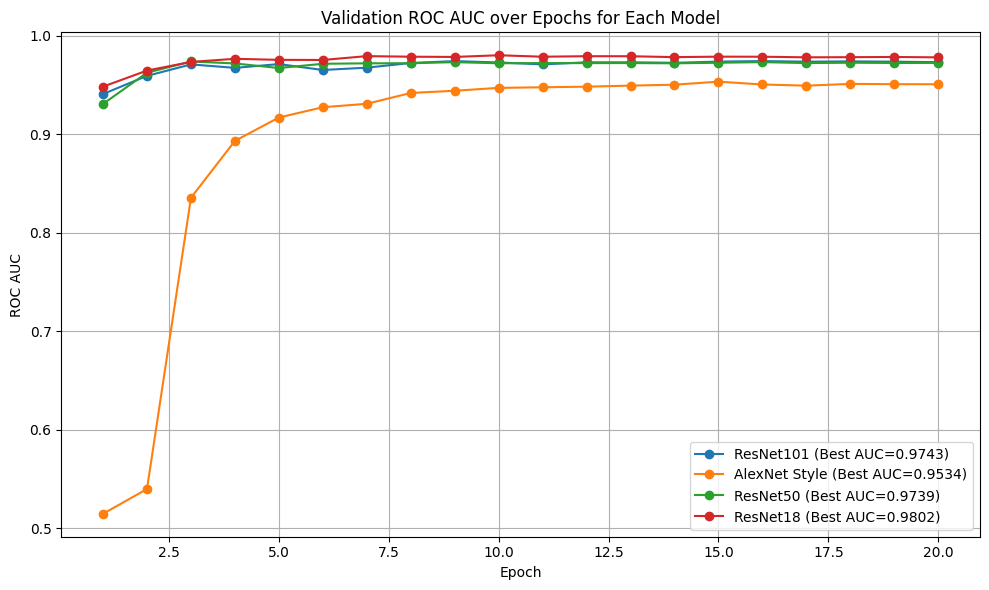

In [15]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Your AUC histories
histories = {
    "ResNet101": auc_history_res101,
    "AlexNet Style": auc_history_alex,
    "ResNet50": auc_history_res50,
    "ResNet18": auc_history_res18,
}

# Your models (make sure they're loaded and moved to device)
models = {
    "ResNet101": model_res101,
    "AlexNet Style": model_alex_1,
    "ResNet50": model_res50,
    "ResNet18": model_res18,
}

# Calculate accuracies
def evaluate_accuracy(model, val_dl, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_dl:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy_score(all_labels.numpy(), all_preds.numpy())
    return acc

print("Model Accuracies on Validation Set:")
for model_name, model in models.items():
    acc = evaluate_accuracy(model, val_dl)
    print(f"{model_name}: {acc:.4f}")

# Plot AUC curves
plt.figure(figsize=(10, 6))

for model_name, auc_history in histories.items():
    epochs = range(1, len(auc_history) + 1)
    best_auc = max(auc_history)
    plt.plot(epochs, auc_history, marker='o', label=f"{model_name} (Best AUC={best_auc:.4f})")

plt.title("Validation ROC AUC over Epochs for Each Model")
plt.xlabel("Epoch")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
##### NEED TO USE THIS WHEN LOADING THE RESNET MODELs AFTER TRAINING OR YOU WILL LOSE A FEW LAYER'S WIEGHTS
import torch
import torch.nn as nn
from torchvision import models

class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()
        
        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model


# This shows how to load in the models. Note you will need 

In [17]:
import torch

# Paths to your saved best models
checkpoint_paths = {
    "resnet18": "working/best_model_res18_label_fix.pt",
    "resnet50": "working/best_model_res50_label_fix.pt",
    "resnet101": "working/best_model_res101_label_fix.pt",
    "alexnet": "working/best_model_alex1_label_fix.pt",
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models properly
model_res18_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

model_res50_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet50"],
    num_classes=num_classes,
    backbone_name="resnet50"
)

model_res101_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet101"],
    num_classes=num_classes,
    backbone_name="resnet101"
)

# AlexNet-style CNN loading (separate because it’s not ResNet)
model_alex_1_load = MelCNN(num_classes)
model_alex_1_load.load_state_dict(torch.load(checkpoint_paths["alexnet"], map_location="cpu"))
model_alex_1_load.eval()

# Move models to device
model_res18_load = model_res18_load.to(device)
model_res50_load = model_res50_load.to(device)
model_res101_load = model_res101_load.to(device)
model_alex_1_load = model_alex_1_load.to(device)

# Evaluate models
roc_auc_res18 = evaluate_roc_auc(model_res18_load, val_dl, device, num_classes)
roc_auc_res50 = evaluate_roc_auc(model_res50_load, val_dl, device, num_classes)
roc_auc_res101 = evaluate_roc_auc(model_res101_load, val_dl, device, num_classes)
roc_auc_alex = evaluate_roc_auc(model_alex_1_load, val_dl, device, num_classes)

# Print results
print(f"ResNet18 Validation ROC AUC: {roc_auc_res18:.4f}")
print(f"ResNet50 Validation ROC AUC: {roc_auc_res50:.4f}")
print(f"ResNet101 Validation ROC AUC: {roc_auc_res101:.4f}")
print(f"AlexNet-style Validation ROC AUC: {roc_auc_alex:.4f}")


ResNet18 Validation ROC AUC: 0.9750
ResNet50 Validation ROC AUC: 0.9722
ResNet101 Validation ROC AUC: 0.9715
AlexNet-style Validation ROC AUC: 0.9483


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_confusion_matrix_top_classes(model, val_dl, num_classes, device, label_encoder, top_n=5, bottom_n=None):
    """
    Predicts on val_dl, builds confusion matrix, and plots top-N or bottom-N classes based on frequency.

    Args:
        model: Trained PyTorch model.
        val_dl: Validation DataLoader.
        num_classes: Total number of classes.
        device: Torch device ("cpu" or "cuda").
        label_encoder: LabelEncoder instance used during training.
        top_n: Number of most common classes to visualize (if bottom_n is None).
        bottom_n: Number of least common classes to visualize (overrides top_n if given).
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for mel_batch, label_batch in val_dl:
            mel_batch = mel_batch.to(device)
            preds = model.predict(mel_batch)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(label_batch.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Build confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    # Normalize confusion matrix
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-6)

    # Select classes based on top_n or bottom_n
    class_counts = np.bincount(all_labels, minlength=num_classes)

    # Only consider classes that appear at least once
    valid_classes = np.where(class_counts > 0)[0]

    if bottom_n is not None:
        # Among valid classes, pick the bottom_n least frequent
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[:bottom_n]]
        title_suffix = f"Bottom {bottom_n} Classes (with at least 1 sample)"
    else:
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[-top_n:]]
        title_suffix = f"Top {top_n} Classes"

    # Extract submatrix for selected classes
    cm_selected = cm_norm[np.ix_(selected_classes, selected_classes)]

    # Get real class labels from LabelEncoder
    selected_class_labels = [label_encoder.inverse_transform([i])[0] for i in selected_classes]

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_selected, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=selected_class_labels, yticklabels=selected_class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Normalized Confusion Matrix ({title_suffix})")
    plt.tight_layout()
    plt.show()


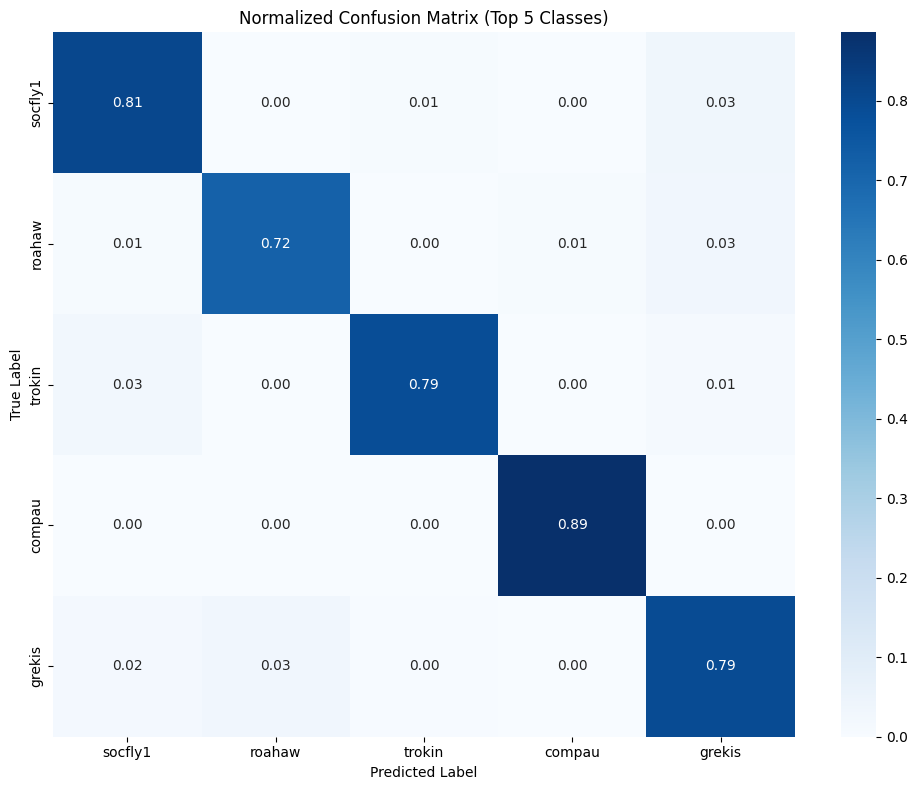

In [19]:
plot_confusion_matrix_top_classes(model_res18_load, val_dl, num_classes, device, label_encoder, top_n=5)

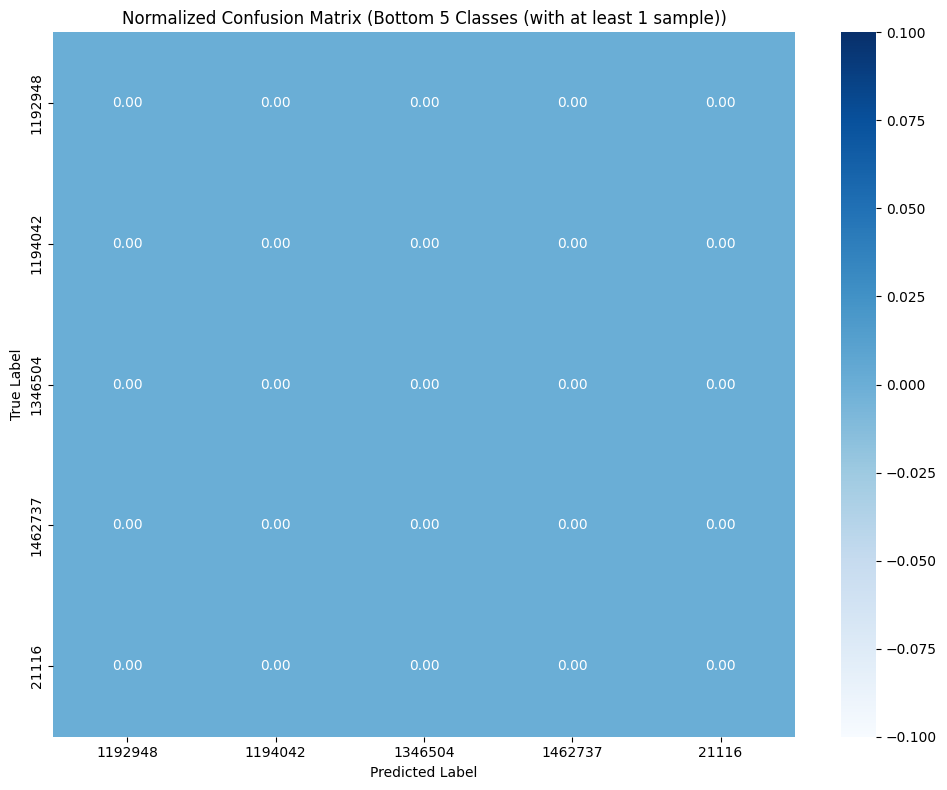

In [20]:
plot_confusion_matrix_top_classes(model_res50_load, val_dl, num_classes, device, label_encoder, bottom_n=5)

As you can see, with normal training, classes with few samples are never predicted because there are too few. I was using Focal Loss to address this with good results (but that is in another notebook not to confuse anyone). We can rerun this if we want with Focal Loss training, let me know.

This confusion matrix is correct — these classes are just not mixed up with one another; they are simply predicted as other, more common classes all of the time.

In [21]:
import numpy as np
import os

# Extract sample names from datasets
train_names = train_dl.dataset.samples
val_names = val_dl.dataset.samples

# Save them
np.save(os.path.join(config.OUTPUT_DIR, "train_names.npy"), np.array(train_names))
np.save(os.path.join(config.OUTPUT_DIR, "val_names.npy"), np.array(val_names))

print(f"Saved {len(train_names)} training samples and {len(val_names)} validation samples.")
import joblib

# Save label encoder
joblib.dump(label_encoder, os.path.join(config.OUTPUT_DIR, "label_encoder.pkl"))
print("✅ Saved LabelEncoder.")


Saved 22851 training samples and 5713 validation samples.
✅ Saved LabelEncoder.


In [22]:
import numpy as np
import os

def save_val_dl(val_dl, save_dir):
    """
    Save full val_dl sample names and labels to disk.
    """
    save_path = os.path.join(save_dir, "val_dl_full.npz")
    
    sample_names = val_dl.dataset.samples
    labels = [label.item() for _, label in val_dl.dataset]  # extract labels

    np.savez_compressed(save_path, sample_names=sample_names, labels=labels)
    
    print(f"✅ Saved validation dataset ({len(sample_names)} samples) to {save_path}")
save_val_dl(val_dl, config.OUTPUT_DIR)


✅ Saved validation dataset (5713 samples) to working/val_dl_full.npz
